<a href="https://colab.research.google.com/github/smartanilmali234-art/Anilmali/blob/main/W04_Ensemble_Learning_RandomForest_vs_XGBoost_AutoMPG_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4: Ensemble Learning — Random Forest vs XGBoost

## Auto MPG Prediction

This project compares traditional machine learning models with ensemble learning models for predicting automobile fuel efficiency.

### Models Used
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- XGBoost Regressor

### Evaluation Metrics
- RMSE
- R² Score

## 1. Objective

The objective of this assignment is to understand ensemble learning by comparing Random Forest and XGBoost with earlier single models.

The Auto MPG dataset is used to predict the fuel efficiency of automobiles measured in miles per gallon (MPG).

In [17]:
!pip install xgboost

## 2. Import Libraries

The required Python libraries are imported for data processing, visualization, model training, and evaluation.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

## 3. Load Dataset

The `auto-mpg.csv` dataset contains information about automobiles such as cylinders, displacement, horsepower, weight, acceleration, model year, and origin.

In [19]:
df = pd.read_csv("auto-mpg.csv")

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


## 4. Explore the Dataset

We inspect the shape, columns, data types, and statistical information of the dataset.

In [20]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (398, 9)

Columns:
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin', 'car name']

Data Types:
mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object

Missing Values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Statistical Summary:


,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


## 5. Data Cleaning

The horsepower column contains some values represented as `?`.

These values are converted to missing values and then removed.

The `car name` column is not required for this regression task, so it is removed.

In [21]:
df["horsepower"] = pd.to_numeric(
    df["horsepower"],
    errors="coerce"
)

df.dropna(inplace=True)

if "car name" in df.columns:
    df.drop("car name", axis=1, inplace=True)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1


## 6. Check Cleaned Dataset

After cleaning, we check the number of rows and confirm that no missing values remain.

In [22]:
print("Cleaned Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

Cleaned Dataset Shape: (392, 8)

Missing Values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
dtype: int64


## 7. Define Features and Target

The target variable is `mpg`.

All other numerical columns are used as input features for predicting MPG.

In [23]:
X = df.drop("mpg", axis=1)
y = df["mpg"]

print("Features:")
print(X.columns.tolist())

print("\nTarget: mpg")

Features:
['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']

Target: mpg


## 8. Split the Dataset

The dataset is divided into:

- 80% training data
- 20% testing data

The training data is used to learn patterns, while the testing data is used to evaluate model performance.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 313
Testing samples: 79


## 9. Train Linear Regression

Linear Regression is used as the baseline single model.

It attempts to predict MPG by learning a linear relationship between the automobile features and fuel efficiency.

In [25]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_pred)
)

linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R²:", linear_r2)

Linear Regression RMSE: 3.2727457003009515
Linear Regression R²: 0.7901500386760351


## 10. Train Decision Tree Regressor

Decision Tree Regressor is another single-tree model.

It makes predictions by splitting the data into smaller groups based on feature values.

In [26]:
dt_model = DecisionTreeRegressor(
    max_depth=6,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_rmse = np.sqrt(
    mean_squared_error(y_test, dt_pred)
)

dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree R²:", dt_r2)

Decision Tree RMSE: 3.023789949201078
Decision Tree R²: 0.8208620459151013


## 11. Train Random Forest Regressor

Random Forest is an ensemble learning method.

It creates many decision trees independently and combines their predictions. This generally makes the model more stable and reduces the risk of relying on a single tree.

In [27]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest RMSE: 2.3695515779329557
Random Forest R²: 0.889993916133405


## 12. Train XGBoost Regressor

XGBoost is a gradient boosting ensemble algorithm.

It builds trees sequentially, with each new tree attempting to reduce the errors made by the previous trees.

In [28]:
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R²:", xgb_r2)

XGBoost RMSE: 2.5094471527430566
XGBoost R²: 0.8766212176139145


## 13. Model Performance Comparison

The four models are compared using RMSE and R².

### Interpretation
- Lower RMSE is better.
- Higher R² is better.

In [29]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE": [
        linear_rmse,
        dt_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R² Score": [
        linear_r2,
        dt_r2,
        rf_r2,
        xgb_r2
    ]
})

results.round(4)

,Model,RMSE,R² Score
0,Linear Regression,3.2727,0.7902
1,Decision Tree,3.0238,0.8209
2,Random Forest,2.3696,0.8900
3,XGBoost,2.5094,0.8766


## 14. Visualize Model Comparison

The following charts compare RMSE and R² scores for all four models.

A strong regression model should have a low RMSE and a high R² score.

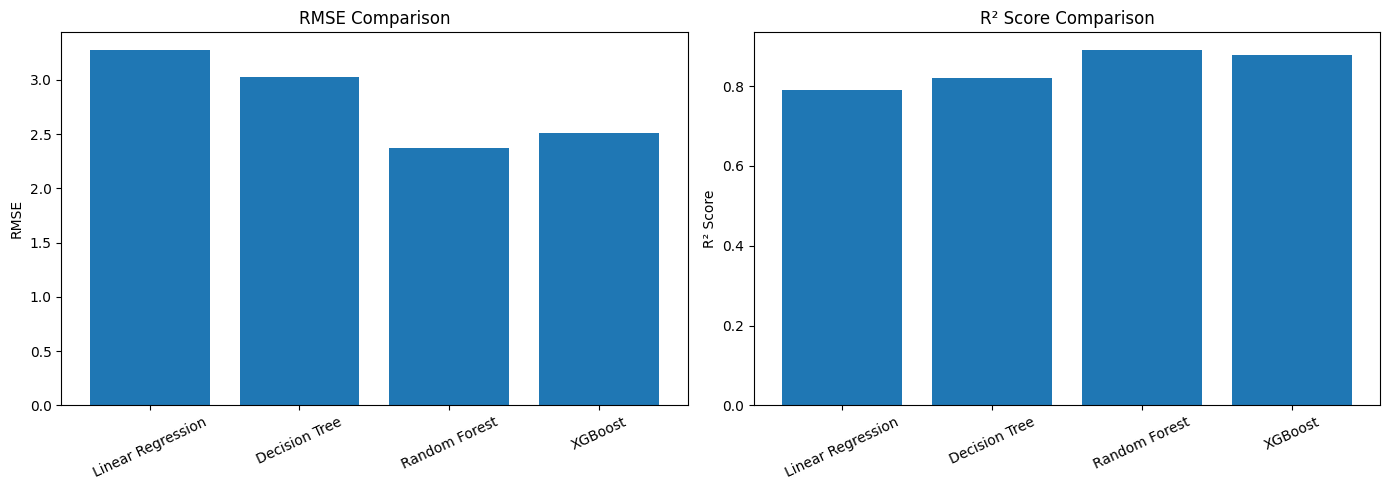

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(results["Model"], results["RMSE"])
axes[0].set_title("RMSE Comparison")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(results["Model"], results["R² Score"])
axes[1].set_title("R² Score Comparison")
axes[1].set_ylabel("R² Score")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## 15. Random Forest Feature Importance

Random Forest provides feature importance scores.

These scores indicate which automobile features were most useful for predicting MPG.

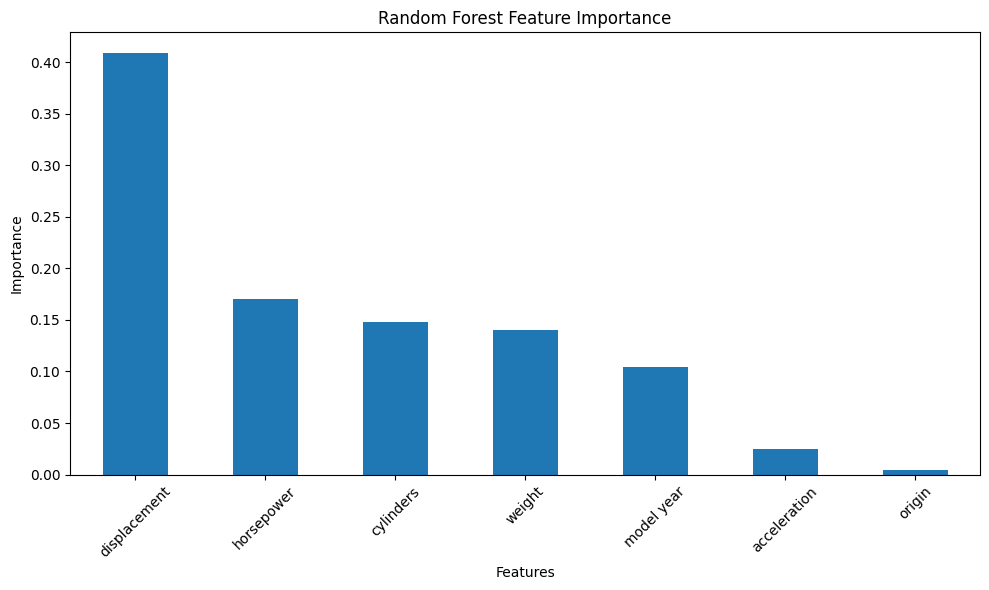

In [31]:
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

rf_importance.plot(kind="bar")

plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 16. XGBoost Feature Importance

XGBoost also provides feature importance scores.

Comparing Random Forest and XGBoost feature importance helps us understand which automobile characteristics are considered important by each ensemble model.

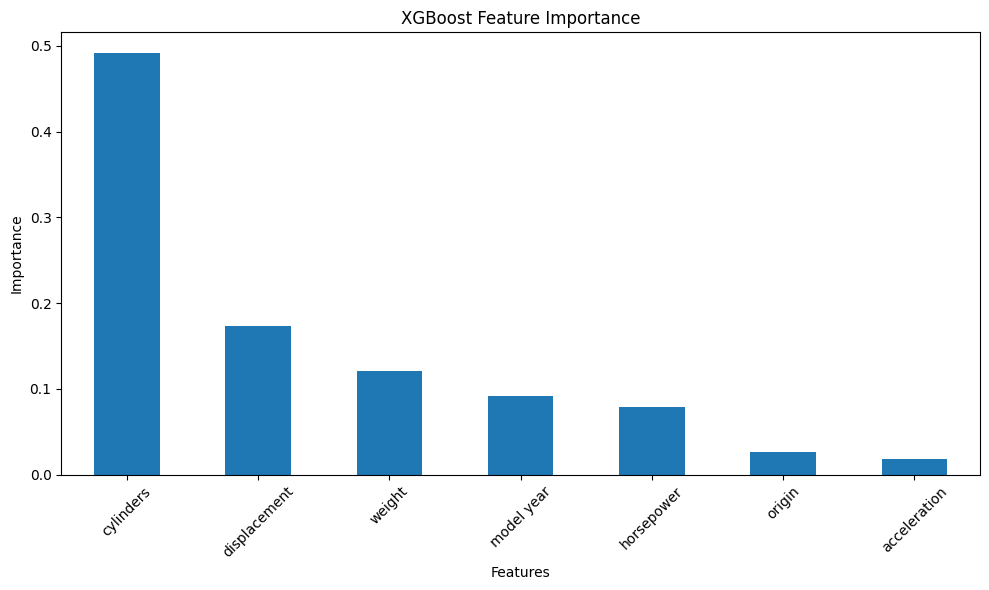

In [32]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

xgb_importance.plot(kind="bar")

plt.title("XGBoost Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()